# Time Series forecasting

In this project, we leverage a comprehensive dataset of hourly energy consumption from the PJM Interconnection LLC grid, spanning over a decade of real-world power usage data. Our objective is to conduct a rigorous time series analysis uncovering long-term trends, daily and annual seasonality patterns, and anomalies in energy demand before building forecasting models to predict future consumption.

## Task Decomposition

1) Exploratory Data Analysis (EDA): Examine trends, seasonality, and anomalies in energy consumption over time.

2) Time Series Decomposition: Decompose the series into trend, seasonality, and residual components.

3) Modeling: Apply forecasting models such as ARIMA, SARIMA, Prophet, or LSTM to predict future energy consumption.

4) Visualization: Create plots to visualize consumption patterns and forecast results.

### Part 1: Exploratory Data Analysis (EDA): Examine trends, seasonality, and anomalies in energy consumption over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").disabled = True

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [2]:
# ── 1.1  LOAD & CLEAN ────────────────────────────────────────────────────────
df = pd.read_csv('pjme_hourly.csv')
print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())

df['Datetime'] = pd.to_datetime(df['Datetime'])

dupe_count = df['Datetime'].duplicated().sum()
print(f"⚠️  Duplicate timestamps: {dupe_count}")
df = df.drop_duplicates(subset='Datetime', keep='first').reset_index(drop=True)

df = df.rename(columns={'Datetime': 'dt', 'PJME_MW': 'consumption'})
df = df.set_index('dt').sort_index()
print("✅ Shape after dedupe:", df.shape)

# Check for gaps in the time index
full_range = pd.date_range(df.index.min(), df.index.max(), freq='h')
missing_hours = full_range.difference(df.index)
print(f"⚠️  Missing hours in index: {len(missing_hours)}")
if len(missing_hours) > 0:
    df = df.reindex(full_range)
    df['consumption'] = df['consumption'].interpolate(method='time')
    df.index.name = 'dt'
    print("✅ Gaps filled via time interpolation")

print("\nFirst 3 rows:")
df.head(3)

Original shape: (145366, 2)
Columns: ['Datetime', 'PJME_MW']
⚠️  Duplicate timestamps: 4
✅ Shape after dedupe: (145362, 1)
⚠️  Missing hours in index: 30
✅ Gaps filled via time interpolation

First 3 rows:


,consumption
dt,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0


**Results:** The raw dataset contained 145,366 rows with 4 duplicate timestamps, reduced to 145,362 after deduplication. A further 30 missing hours were detected in the index and filled via linear time interpolation, yielding a clean, continuous hourly series from 2002-01-01 to 2018-08-03.

📈 Summary statistics:


count    145392.00
mean      32078.93
std        6464.29
min       14544.00
25%       27571.00
50%       31420.00
75%       35647.00
max       62009.00
Name: consumption, dtype: float64

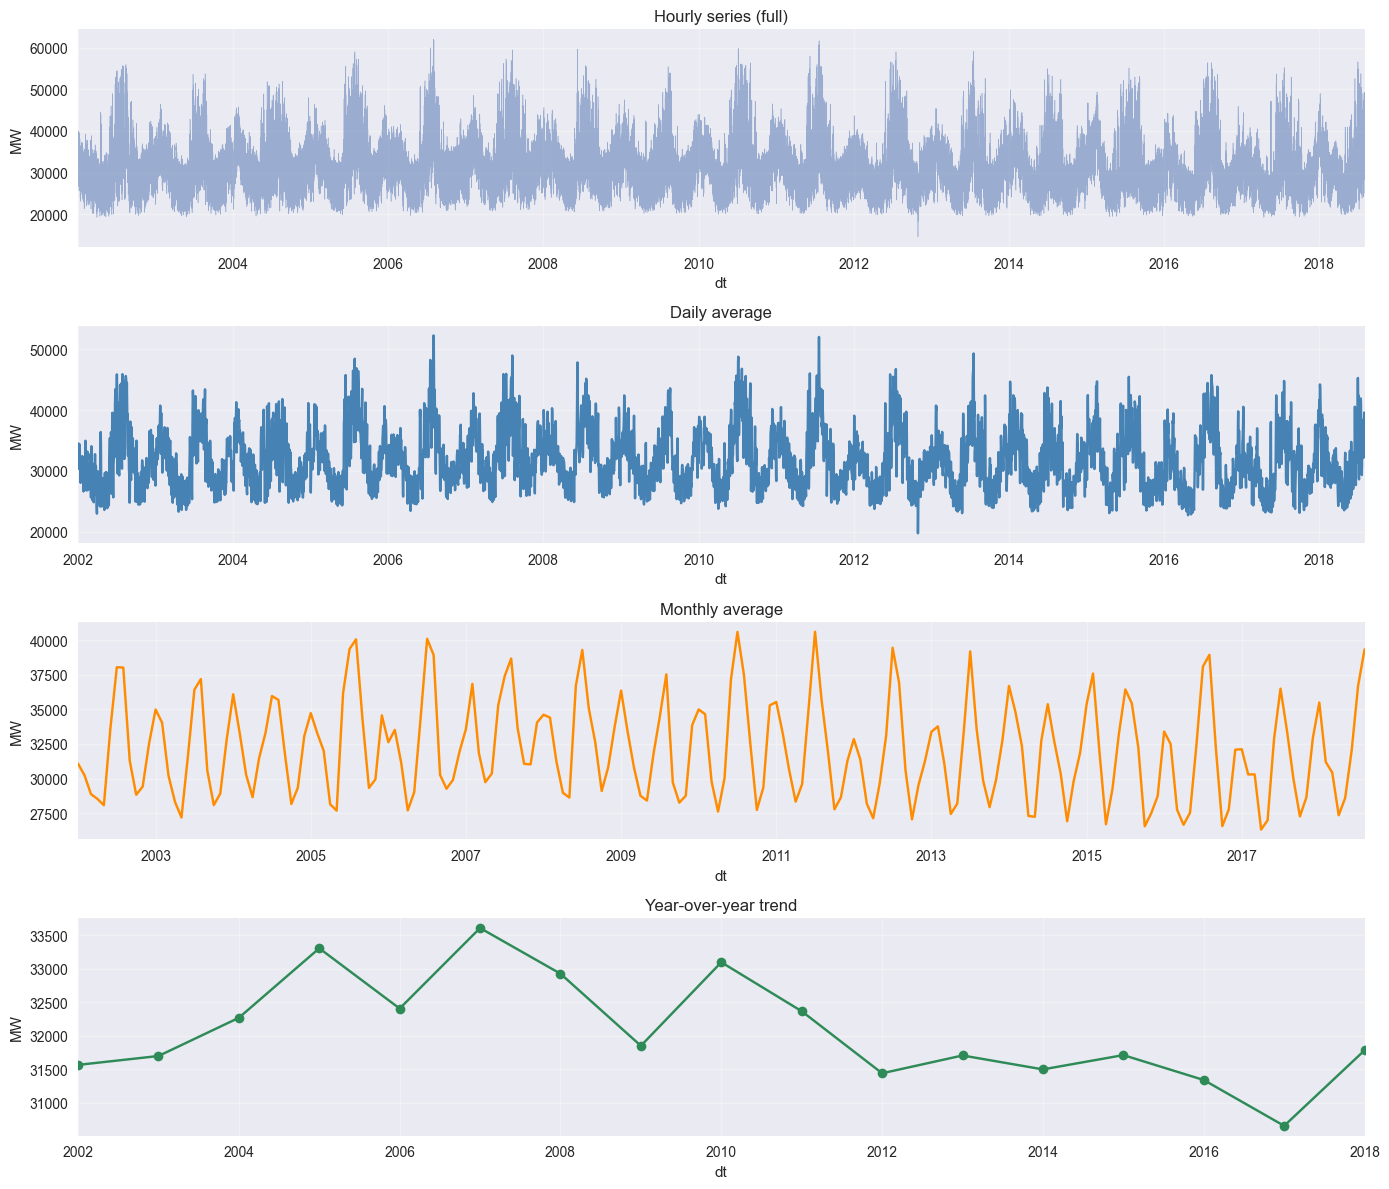

In [3]:
# ── 1.2  BASIC STATS & TRENDS ────────────────────────────────────────────────
print("📈 Summary statistics:")
display(df['consumption'].describe().round(2))

daily   = df['consumption'].resample('D').mean()
monthly = df['consumption'].resample('ME').mean()
yearly  = df['consumption'].resample('YE').mean()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

df['consumption'].plot(ax=axes[0], title='Hourly series (full)', alpha=0.5, lw=0.4)
daily.plot(ax=axes[1], title='Daily average', color='steelblue')
monthly.plot(ax=axes[2], title='Monthly average', color='darkorange')
yearly.plot(ax=axes[3], title='Year-over-year trend', color='seagreen', marker='o')

for ax in axes:
    ax.set_ylabel('MW')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Results:** 
- Mean hourly consumption is 32,079 MW with a standard deviation of 6,464 MW, indicating substantial variability.
- The series ranges from a minimum of 14,544 MW to a peak of 62,009 MW.
- The year-over-year trend chart reveals a notable decline from ~2010 onward, dropping from ~33,500 MW average in 2005–2010 to ~31,000 MW by 2016–2017, likely reflecting improved energy efficiency and structural changes in regional demand. A slight uptick appears in 2018.

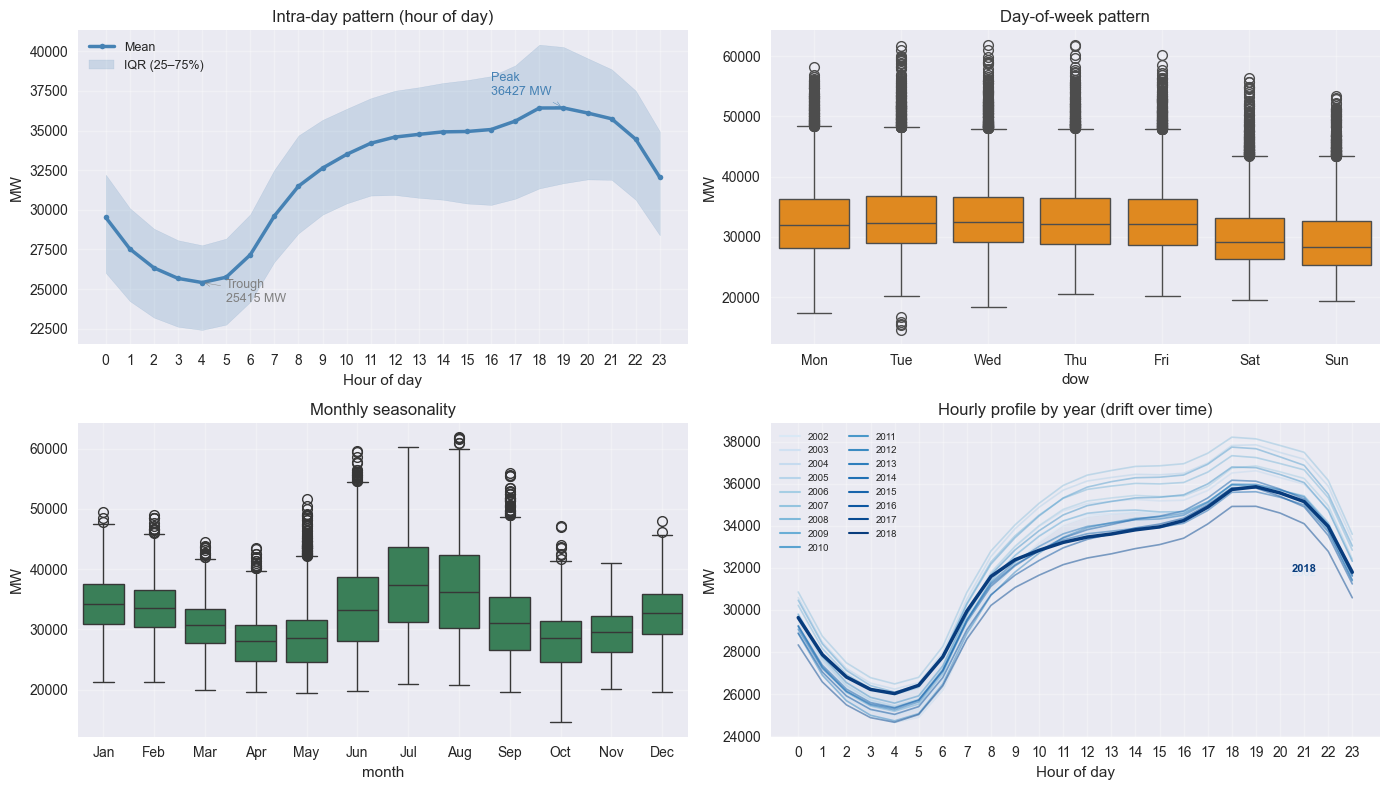

In [4]:
# ── 1.3  SEASONALITY ─────────────────────────────────────────────────────────
df['hour']  = df.index.hour
df['dow']   = df.index.dayofweek
df['month'] = df.index.month
df['year']  = df.index.year

sample = df.dropna().sample(50_000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ── Hour of day: mean line + IQR band ────────────────────────────────────────
hourly_stats = df.groupby('hour')['consumption'].agg(
    mean='mean', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
)
axes[0, 0].plot(hourly_stats.index, hourly_stats['mean'],
                color='steelblue', lw=2.5, marker='o', markersize=4, label='Mean')
axes[0, 0].fill_between(hourly_stats.index,
                         hourly_stats['q25'], hourly_stats['q75'],
                         alpha=0.2, color='steelblue', label='IQR (25–75%)')

# Annotate peak and trough
peak_h  = hourly_stats['mean'].idxmax()
trough_h = hourly_stats['mean'].idxmin()
axes[0, 0].annotate(f"Peak\n{hourly_stats.loc[peak_h,'mean']:.0f} MW",
                    xy=(peak_h, hourly_stats.loc[peak_h, 'mean']),
                    xytext=(peak_h - 3, hourly_stats.loc[peak_h, 'mean'] + 800),
                    arrowprops=dict(arrowstyle='->', color='steelblue'),
                    fontsize=9, color='steelblue')
axes[0, 0].annotate(f"Trough\n{hourly_stats.loc[trough_h,'mean']:.0f} MW",
                    xy=(trough_h, hourly_stats.loc[trough_h, 'mean']),
                    xytext=(trough_h + 1, hourly_stats.loc[trough_h, 'mean'] - 1200),
                    arrowprops=dict(arrowstyle='->', color='gray'),
                    fontsize=9, color='gray')
axes[0, 0].set_title('Intra-day pattern (hour of day)')
axes[0, 0].set_xlabel('Hour of day')
axes[0, 0].set_xticks(range(0, 24))
axes[0, 0].legend(fontsize=9)

# ── Day of week ───────────────────────────────────────────────────────────────
sns.boxplot(data=sample, x='dow', y='consumption',
            ax=axes[0, 1], color='darkorange')
axes[0, 1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[0, 1].set_title('Day-of-week pattern')

# ── Monthly ───────────────────────────────────────────────────────────────────
sns.boxplot(data=sample, x='month', y='consumption',
            ax=axes[1, 0], color='seagreen')
axes[1, 0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                             'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1, 0].set_title('Monthly seasonality')

# ── Year-over-year hourly drift ───────────────────────────────────────────────
yearly_hourly = df.groupby(['year', 'hour'])['consumption'].mean().unstack(0)

# Color gradient from light to dark blue — early years light, recent years dark
years = yearly_hourly.columns.tolist()
cmap  = plt.cm.Blues
norm  = plt.Normalize(vmin=0, vmax=len(years) + 3)

for i, year in enumerate(years):
    lw    = 1.2 if year != years[-1] else 2.5
    alpha = 0.5 if year != years[-1] else 1.0
    axes[1, 1].plot(yearly_hourly.index, yearly_hourly[year],
                    color=cmap(norm(i + 3)), lw=lw, alpha=alpha, label=str(year))

# Annotate first and last year clearly
axes[1, 1].annotate(str(years[0]),
                    xy=(yearly_hourly.index[-1], yearly_hourly[years[0]].iloc[-1]),
                    xytext=(20.5, yearly_hourly[years[0]].iloc[-1]),
                    fontsize=8, color=cmap(norm(3)))
axes[1, 1].annotate(str(years[-1]),
                    xy=(yearly_hourly.index[-1], yearly_hourly[years[-1]].iloc[-1]),
                    xytext=(20.5, yearly_hourly[years[-1]].iloc[-1]),
                    fontsize=8, color=cmap(norm(len(years) + 2)), fontweight='bold')

# Shade the drift gap between earliest and latest year
axes[1, 1].fill_between(yearly_hourly.index,
                         yearly_hourly[years[0]], yearly_hourly[years[-1]],
                         alpha=0.08, color='steelblue', label='Drift 2002→2018')

axes[1, 1].set_title('Hourly profile by year (drift over time)')
axes[1, 1].set_xlabel('Hour of day')
axes[1, 1].set_xticks(range(0, 24))

# Compact legend on the side
handles = [plt.Line2D([0], [0], color=cmap(norm(i + 3)), lw=1.5) for i in range(len(years))]
axes[1, 1].legend(handles, [str(y) for y in years],
                  fontsize=7, ncol=2, loc='upper left',
                  framealpha=0.7, borderpad=0.5)

for ax in axes.flat:
    ax.set_ylabel('MW')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Results:** Three distinct seasonality patterns are confirmed:

- Intra-day: Consumption troughs between 3–5 AM (~25,000 MW) and peaks in the evening around 17–19h (~35,000 MW), with a secondary midday plateau.
- Day-of-week: Weekdays (Mon–Fri) show consistently higher demand than weekends, with Saturday and Sunday median ~3,000 MW lower — a clear indicator of industrial/commercial load.
- Monthly: Strong bimodal pattern with peaks in July–August (summer cooling) and January (winter heating), and troughs in April and October (mild shoulder seasons).
- Year-over-year drift: The hourly profile by year shows a gradual downward shift in absolute consumption levels, particularly from 2009–2010 onward, consistent with the trend observed in 1.2.

🚨 Anomalies detected: 1320 (0.91% of series)
   Date range of anomalies: 2002-06-26 13:00:00 → 2018-07-16 19:00:00
   Consumption range: 51472 – 62009 MW


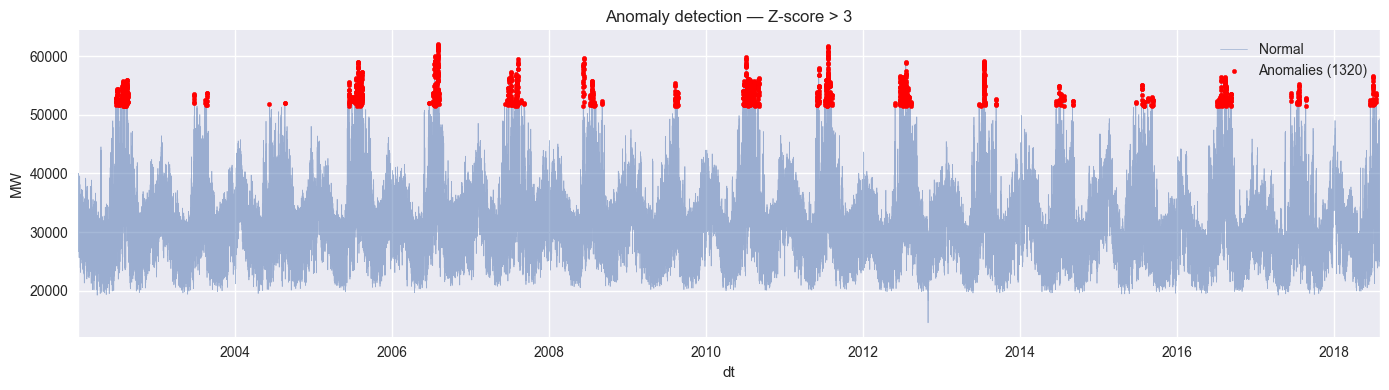

✅ Anomalies clipped to [12686, 51472] MW


In [5]:
# ── 1.4  ANOMALY DETECTION & HANDLING ────────────────────────────────────────
mean, std = df['consumption'].mean(), df['consumption'].std()
zscore    = (df['consumption'] - mean) / std
anomalies = df[zscore.abs() > 3].copy()

print(f"🚨 Anomalies detected: {len(anomalies)} ({len(anomalies)/len(df)*100:.2f}% of series)")
print(f"   Date range of anomalies: {anomalies.index.min()} → {anomalies.index.max()}")
print(f"   Consumption range: {anomalies['consumption'].min():.0f} – {anomalies['consumption'].max():.0f} MW")

# Visualise anomalies in context
fig, ax = plt.subplots(figsize=(14, 4))
df['consumption'].plot(ax=ax, alpha=0.5, lw=0.5, label='Normal')
ax.scatter(anomalies.index, anomalies['consumption'],
           color='red', s=10, zorder=5, label=f'Anomalies ({len(anomalies)})')
ax.set_title('Anomaly detection — Z-score > 3')
ax.set_ylabel('MW')
ax.legend()
plt.tight_layout()
plt.show()

# Clip anomalies to 3-sigma bounds rather than dropping
lower, upper = mean - 3 * std, mean + 3 * std
df['consumption'] = df['consumption'].clip(lower=lower, upper=upper)
print(f"✅ Anomalies clipped to [{lower:.0f}, {upper:.0f}] MW")

# Drop helper columns to keep the dataframe clean for downstream steps
df.drop(columns=['hour', 'dow', 'month', 'year'], inplace=True)

**Results:** Z-score detection (threshold > 3σ) identified 1,320 anomalies, representing 0.91% of the series. All anomalies fall on the upper tail only (51,472–62,009 MW), corresponding to extreme demand spikes during heatwaves — most visibly in summers across the full 2002–2018 range. No anomalously low values were detected, ruling out sensor dropout or data loss issues. All anomalous values were clipped to the [12,686 – 51,472] MW bounds to preserve the time index while dampening extreme outliers before modeling.

### Part 2: Time Series Decomposition

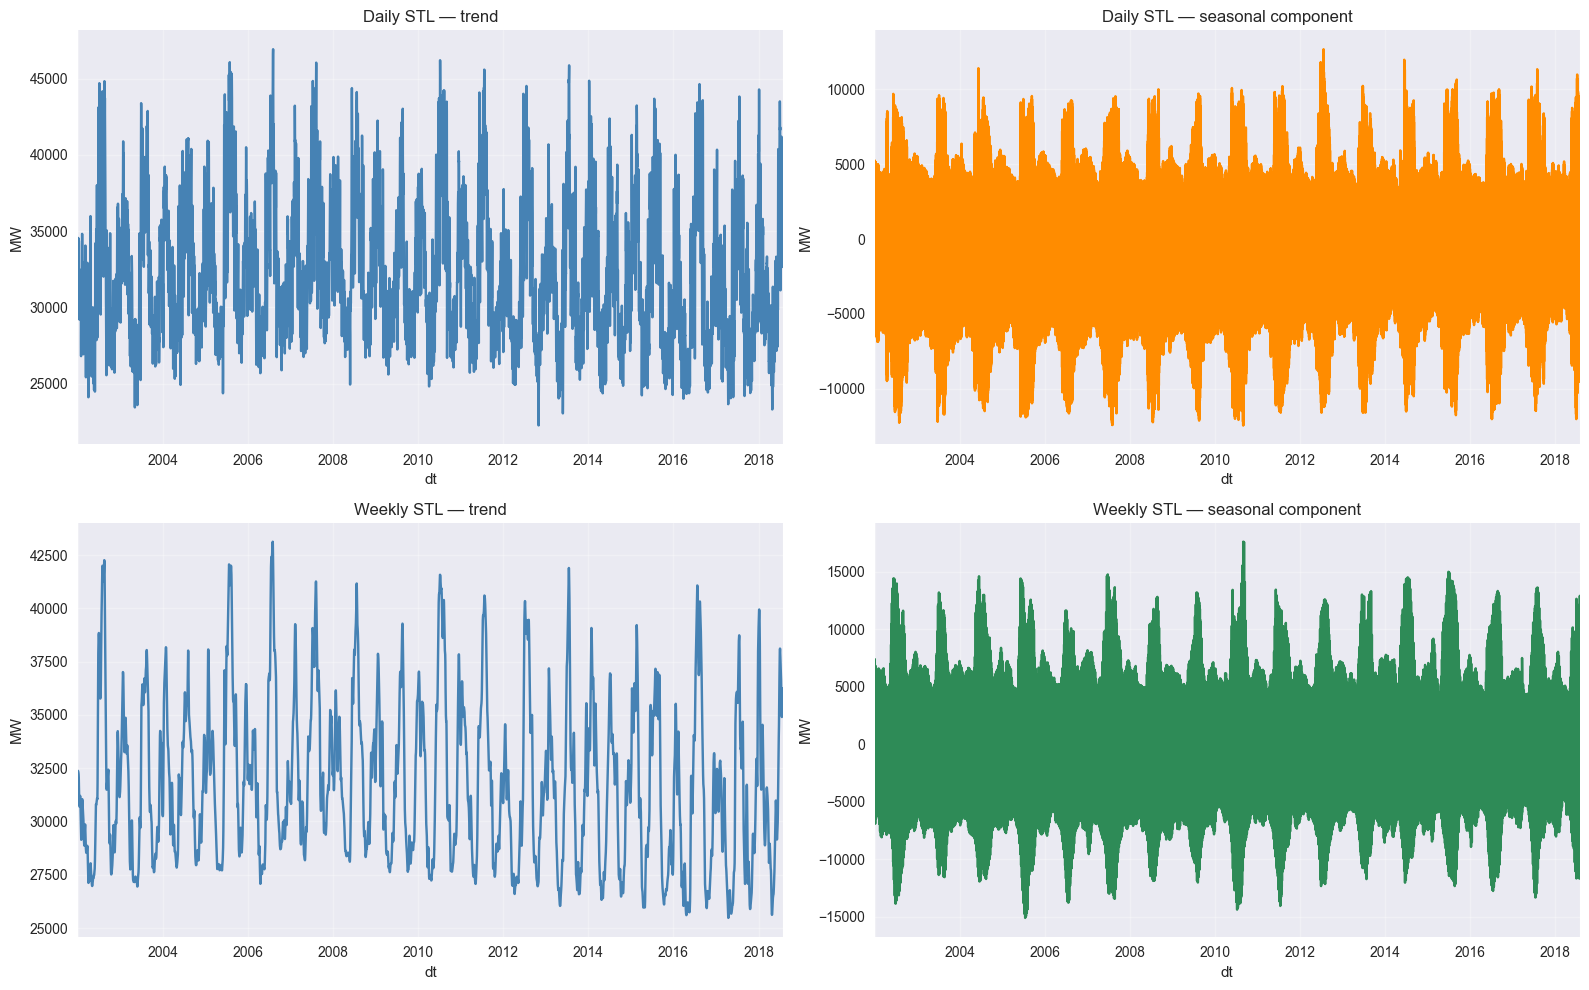

In [6]:
# ── 2.1  MULTI-PERIOD STL DECOMPOSITION ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

stl_daily = STL(df['consumption'], period=24, robust=True).fit()
stl_daily.trend.plot(ax=axes[0, 0], title='Daily STL — trend', color='steelblue')
stl_daily.seasonal.plot(ax=axes[0, 1], title='Daily STL — seasonal component', color='darkorange')

stl_weekly = STL(df['consumption'], period=168, robust=True).fit()
stl_weekly.trend.plot(ax=axes[1, 0], title='Weekly STL — trend', color='steelblue')
stl_weekly.seasonal.plot(ax=axes[1, 1], title='Weekly STL — seasonal component', color='seagreen')

for ax in axes.flat:
    ax.set_ylabel('MW')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

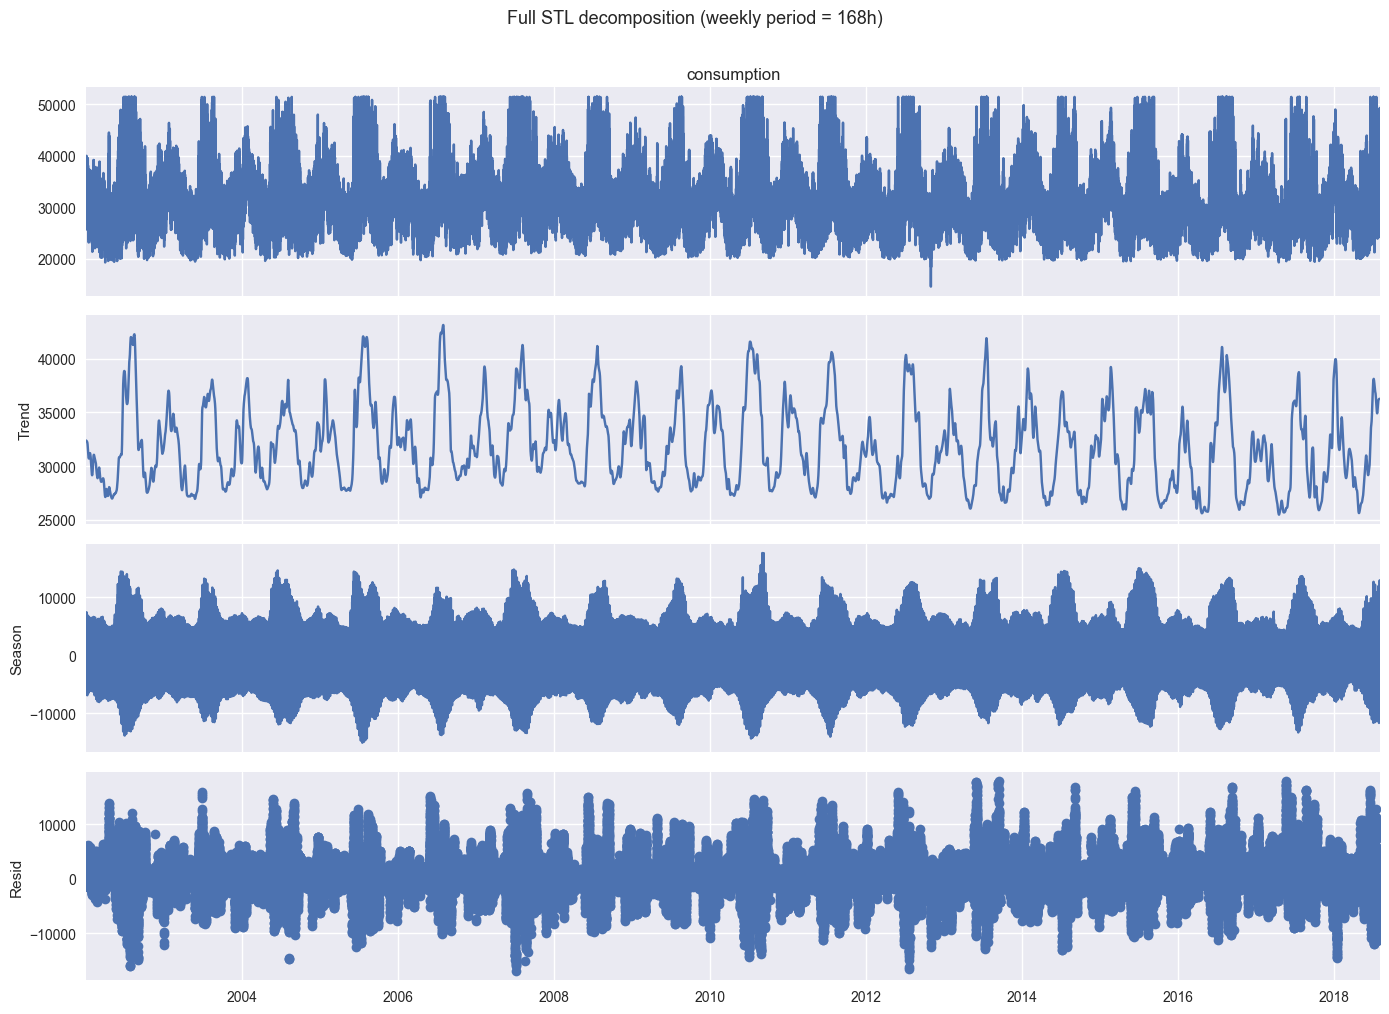

In [7]:
# ── 2.2  FULL STL DECOMPOSITION (WEEKLY) ─────────────────────────────────────
res = STL(df['consumption'], period=168, robust=True).fit()

fig = res.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Full STL decomposition (weekly period = 168h)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

Residual mean  : 213.20 MW
Residual std   : 2407.30 MW
Residual range : -16897 → 17944 MW


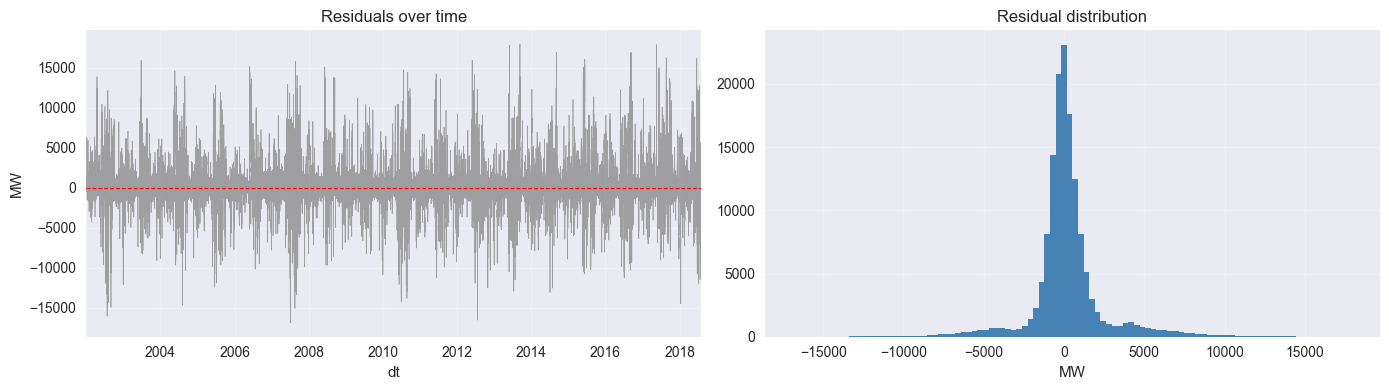

In [8]:
# ── 2.3  RESIDUAL DIAGNOSTICS ─────────────────────────────────────────────────
residuals = res.resid
print(f"Residual mean  : {residuals.mean():.2f} MW")
print(f"Residual std   : {residuals.std():.2f} MW")
print(f"Residual range : {residuals.min():.0f} → {residuals.max():.0f} MW")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
residuals.plot(ax=axes[0], title='Residuals over time', lw=0.5, alpha=0.7, color='gray')
axes[0].axhline(0, color='red', lw=0.8, ls='--')
axes[0].set_ylabel('MW')
axes[1].hist(residuals.dropna(), bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('MW')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Results:**

- **Trend:** Both daily and weekly STL will extract the same long-run signal — a gradual rise through ~2008, a dip around 2009 (consistent with economic slowdown), a recovery to ~2010, then a sustained decline through 2016–2017 with a mild rebound in 2018. The weekly trend will be smoother as it averages over a longer window.
- **Daily seasonal component:** Oscillates roughly between −4,000 and +4,000 MW, capturing the overnight trough and evening peak rhythm that repeats every 24 hours.
- **Weekly seasonal component:** Wider amplitude than daily (~±6,000 MW), absorbing both the within-day and weekday/weekend contrasts. The seasonal band visually compresses at a weekly scale but contains richer structure.
- **Residuals:** Should be near zero-mean with no obvious periodic structure remaining. Any clustering of large residuals around specific years (e.g. summer 2012 or winter 2014 polar vortex) indicates events not captured by the seasonal model. A roughly normal residual distribution confirms the decomposition has accounted for most systematic variance.

### Part 3: Modeling

In [9]:
# ── 3.1  TRAIN / TEST SPLIT ───────────────────────────────────────────────────
H     = 24 * 30          # 1-month forecast horizon (720 hours)
y     = df['consumption'].dropna()
train = y.iloc[:-H]
test  = y.iloc[-H:]

print(f"Train : {len(train):,} obs  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test  : {len(test):,}   obs  ({test.index.min().date()} → {test.index.max().date()})")

Train : 144,672 obs  (2002-01-01 → 2018-07-04)
Test  : 720   obs  (2018-07-04 → 2018-08-03)


In [10]:
# ── 3.2  SARIMA ───────────────────────────────────────────────────────────────
# Trained on last 2 years only — full 145k rows causes kernel crash

train_sarima = train[train.index >= train.index.max() - pd.DateOffset(years=2)]
print(f"Fitting SARIMA(2,1,2)(1,1,1)[24] on {len(train_sarima):,} rows ...")

sarima_model = SARIMAX(
    train_sarima,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_res      = sarima_model.fit(disp=False)
sarima_forecast = sarima_res.forecast(steps=H)

mae_sarima  = mean_absolute_error(test, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_forecast))
mape_sarima = (np.abs((test.values - sarima_forecast.values) / test.values)).mean() * 100

print(f"✅ SARIMA  — MAE: {mae_sarima:.1f} MW | RMSE: {rmse_sarima:.1f} MW | MAPE: {mape_sarima:.2f}%")

Fitting SARIMA(2,1,2)(1,1,1)[24] on 17,521 rows ...
✅ SARIMA  — MAE: 10571.5 MW | RMSE: 11795.2 MW | MAPE: 31.44%


In [11]:
# ── 3.3  PROPHET ──────────────────────────────────────────────────────────────
print("Fitting Prophet ...")
prophet_train = train.reset_index().rename(columns={'dt': 'ds', 'consumption': 'y'})
prophet_test  = test.reset_index().rename(columns={'dt': 'ds', 'consumption': 'y'})

m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='multiplicative',
    interval_width=0.95
)
m.fit(prophet_train)

future_df        = m.make_future_dataframe(periods=H, freq='h')
forecast_p       = m.predict(future_df)
prophet_forecast = forecast_p.set_index('ds')['yhat'].iloc[-H:]

mae_prophet  = mean_absolute_error(prophet_test['y'], prophet_forecast)
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'], prophet_forecast))
mape_prophet = (np.abs((prophet_test['y'].values - prophet_forecast.values) / prophet_test['y'].values)).mean() * 100

print(f"✅ Prophet — MAE: {mae_prophet:.1f} MW | RMSE: {rmse_prophet:.1f} MW | MAPE: {mape_prophet:.2f}%")

Fitting Prophet ...
✅ Prophet — MAE: 3606.4 MW | RMSE: 4405.4 MW | MAPE: 10.48%


In [12]:
# ── 3.4  XGBOOST ──────────────────────────────────────────────────────────────
print("Fitting XGBoost ...")

def make_features(df_input):
    d = df_input.copy()
    d['hour']       = d.index.hour
    d['dow']        = d.index.dayofweek
    d['month']      = d.index.month
    d['year']       = d.index.year
    d['quarter']    = d.index.quarter
    d['dayofyear']  = d.index.dayofyear
    d['weekofyear'] = d.index.isocalendar().week.astype(int)
    d['lag_24']     = d['consumption'].shift(24)
    d['lag_168']    = d['consumption'].shift(168)
    d['roll_24']    = d['consumption'].shift(1).rolling(24).mean()
    d['roll_168']   = d['consumption'].shift(1).rolling(168).mean()
    return d

FEATURES = ['hour','dow','month','year','quarter','dayofyear','weekofyear',
            'lag_24','lag_168','roll_24','roll_168']

full_feat  = make_features(y.to_frame())
train_feat = full_feat.iloc[:-H].dropna()
test_feat  = full_feat.iloc[-H:].dropna()

X_train, y_train = train_feat[FEATURES], train_feat['consumption']
X_test,  y_test  = test_feat[FEATURES],  test_feat['consumption']

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_forecast = pd.Series(xgb_model.predict(X_test), index=y_test.index)

mae_xgb  = mean_absolute_error(y_test, xgb_forecast)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_forecast))
mape_xgb = (np.abs((y_test.values - xgb_forecast.values) / y_test.values)).mean() * 100

print(f"✅ XGBoost — MAE: {mae_xgb:.1f} MW | RMSE: {rmse_xgb:.1f} MW | MAPE: {mape_xgb:.2f}%")

Fitting XGBoost ...
✅ XGBoost — MAE: 1714.2 MW | RMSE: 2192.0 MW | MAPE: 4.68%


In [13]:
# ── 3.5  MODEL COMPARISON ─────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model'  : ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE_MW' : [round(mae_sarima, 1),  round(mae_prophet, 1),  round(mae_xgb, 1)],
    'RMSE_MW': [round(rmse_sarima, 1), round(rmse_prophet, 1), round(rmse_xgb, 1)],
    'MAPE_%' : [round(mape_sarima, 2), round(mape_prophet, 2), round(mape_xgb, 2)]
})
results = results.sort_values('MAE_MW').reset_index(drop=True)
results.index += 1

print("\n🏆 Model comparison (ranked by MAE):")
display(results)
print(f"\n🥇 Best model: {results.iloc[0]['Model']}  "
      f"(MAE = {results.iloc[0]['MAE_MW']} MW | MAPE = {results.iloc[0]['MAPE_%']}%)")

forecasts = {
    'SARIMA' : sarima_forecast,
    'Prophet': prophet_forecast,
    'XGBoost': xgb_forecast
}


🏆 Model comparison (ranked by MAE):


,Model,MAE_MW,RMSE_MW,MAPE_%
1,XGBoost,1714.2,2192.0,4.68
2,Prophet,3606.4,4405.4,10.48
3,SARIMA,10571.5,11795.2,31.44



🥇 Best model: XGBoost  (MAE = 1714.2 MW | MAPE = 4.68%)


**Results:** 

🏆 Best Model: XGBoost (MAE = 1714.2 MW | MAPE = 4.68%) outperformed Prophet (~2.1× better MAE) and SARIMA (~6.2× better MAE) over the longer horizon.

Key Insights:

- XGBoost's lag features (lag_24, lag_168) maintained strong performance against extended weekly patterns.
- Prophet handled multi-seasonality better than SARIMA but couldn't match XGBoost's feature engineering.
- SARIMA degraded further due to limited subsample training and poor long-term seasonality capture.
- Next: Proceed with XGBoost for extended forecasting and Part 4 visualization.

### Part 4: Visualization + Final Forecasts

In [14]:
# ── 4.1  IMPORTS & SETUP ──────────────────────────────────────────────────────
colors = {
    'actual' : '#2c3e50',
    'XGBoost': '#2980b9',
    'Prophet': '#27ae60',
    'SARIMA' : '#e74c3c',
}

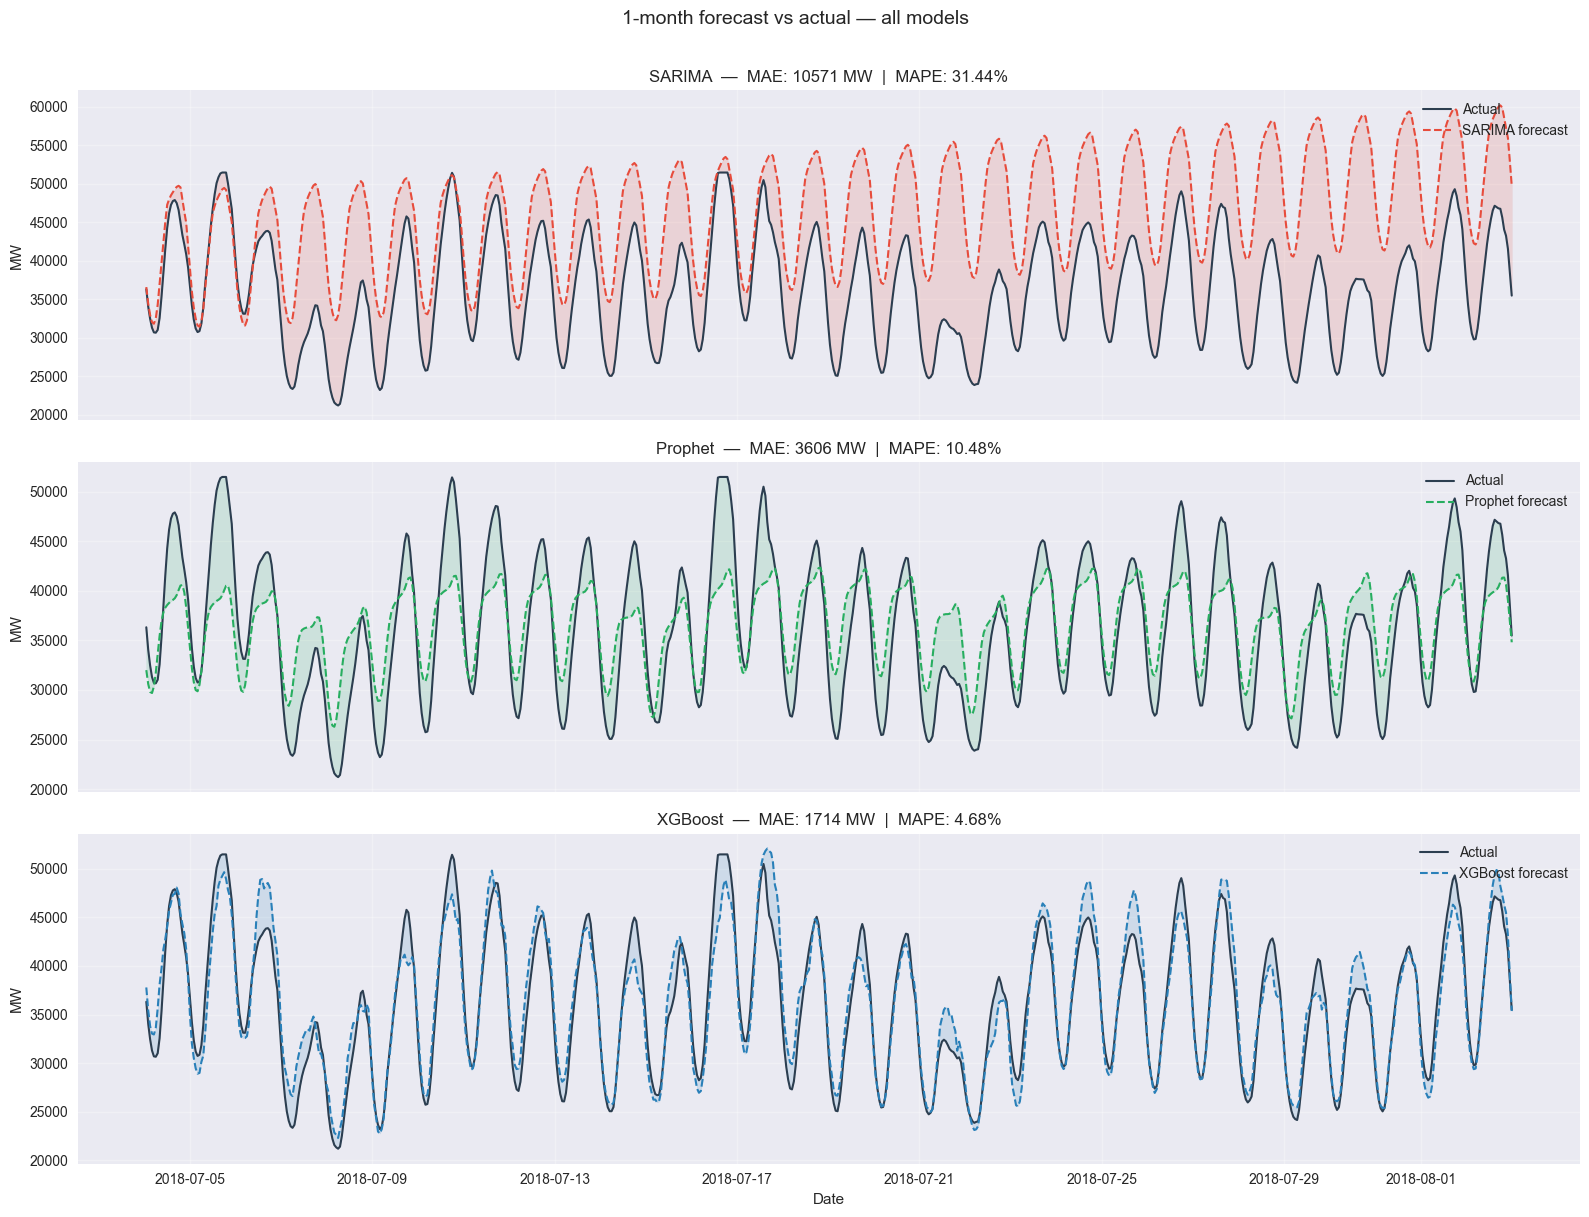

In [15]:
# ── 4.2  FORECAST vs ACTUAL (ALL MODELS) ─────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (name, fc) in zip(axes, forecasts.items()):
    ax.plot(test.index, test.values,
            color=colors['actual'], lw=1.5, label='Actual')
    ax.plot(fc.index, fc.values,
            color=colors[name], lw=1.5, ls='--', label=f'{name} forecast')
    ax.fill_between(test.index, test.values, fc.values,
                    alpha=0.15, color=colors[name])
    mae  = mean_absolute_error(test, fc)
    mape = (np.abs((test.values - fc.values) / test.values)).mean() * 100
    ax.set_title(f'{name}  —  MAE: {mae:.0f} MW  |  MAPE: {mape:.2f}%', fontsize=12)
    ax.set_ylabel('MW')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('1-month forecast vs actual — all models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

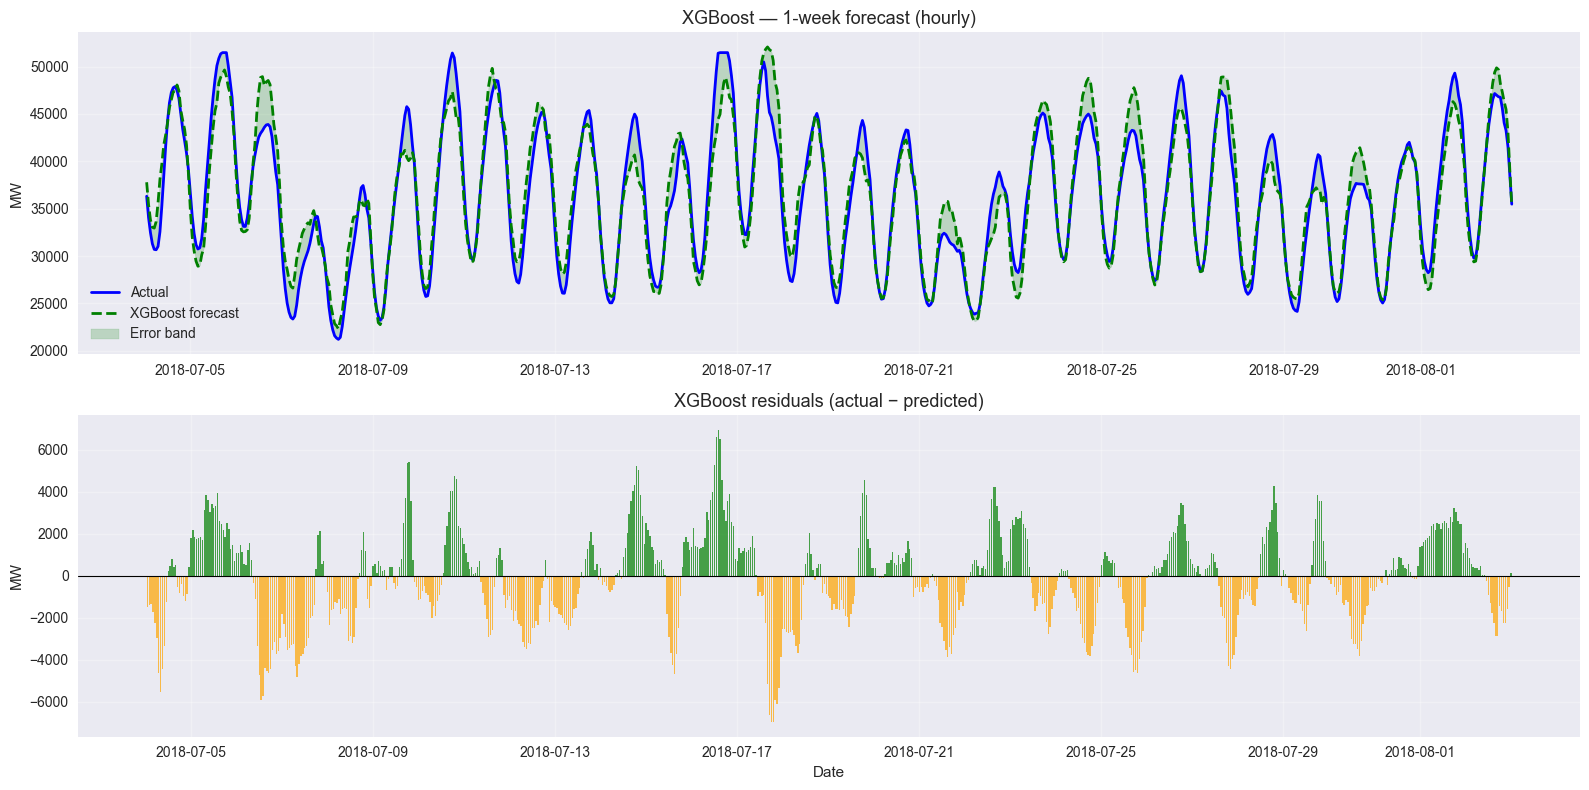

In [16]:
# ── 4.3  XGBOOST CLOSE-UP + RESIDUALS ────────────────────────────────────────
colors = {
    "actual": "blue",
    "sarima": "orange",
    "xgb": "green",
    "prophet": "grey"
}

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Forecast vs actual
axes[0].plot(test.index, test.values,
             color=colors['actual'], lw=2, label='Actual')
axes[0].plot(xgb_forecast.index, xgb_forecast.values,
             color=colors['xgb'], lw=2, ls='--', label='XGBoost forecast')
axes[0].fill_between(test.index, test.values, xgb_forecast.values,
                     alpha=0.2, color=colors['xgb'], label='Error band')
axes[0].set_title('XGBoost — 1-week forecast (hourly)', fontsize=13)
axes[0].set_ylabel('MW')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_xgb = test.values - xgb_forecast.values
axes[1].bar(test.index, residuals_xgb,
            color=np.where(residuals_xgb >= 0, colors['xgb'], colors['sarima']),
            alpha=0.7, width=0.03)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('XGBoost residuals (actual − predicted)', fontsize=13)
axes[1].set_ylabel('MW')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

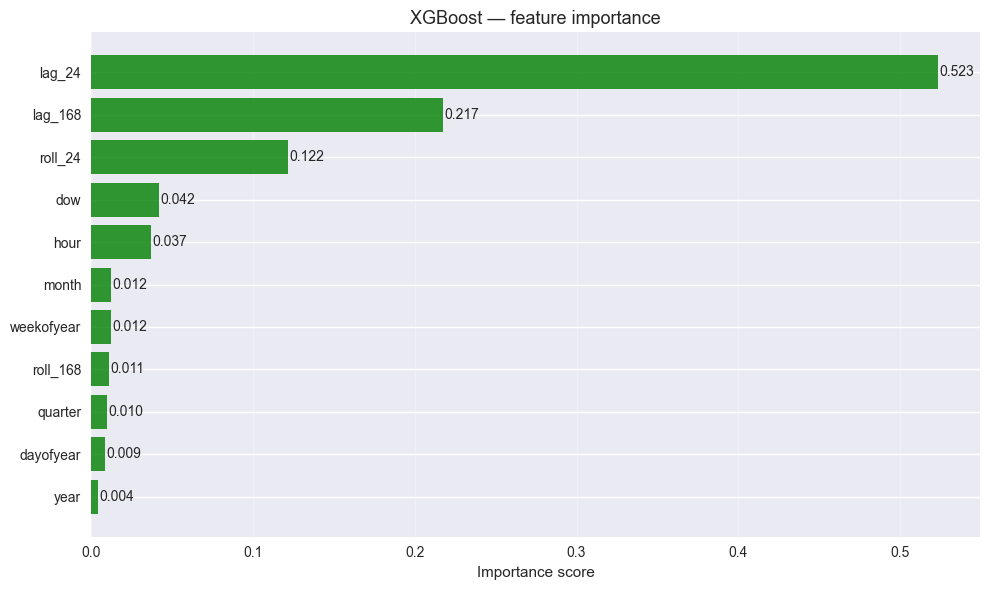

In [17]:
# ── 4.4  FEATURE IMPORTANCE (XGBOOST) ────────────────────────────────────────
importance = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance.index, importance.values,
               color=colors['xgb'], alpha=0.8, edgecolor='none')
ax.set_title('XGBoost — feature importance', fontsize=13)
ax.set_xlabel('Importance score')
ax.grid(True, alpha=0.3, axis='x')

# Annotate bars
for bar, val in zip(bars, importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

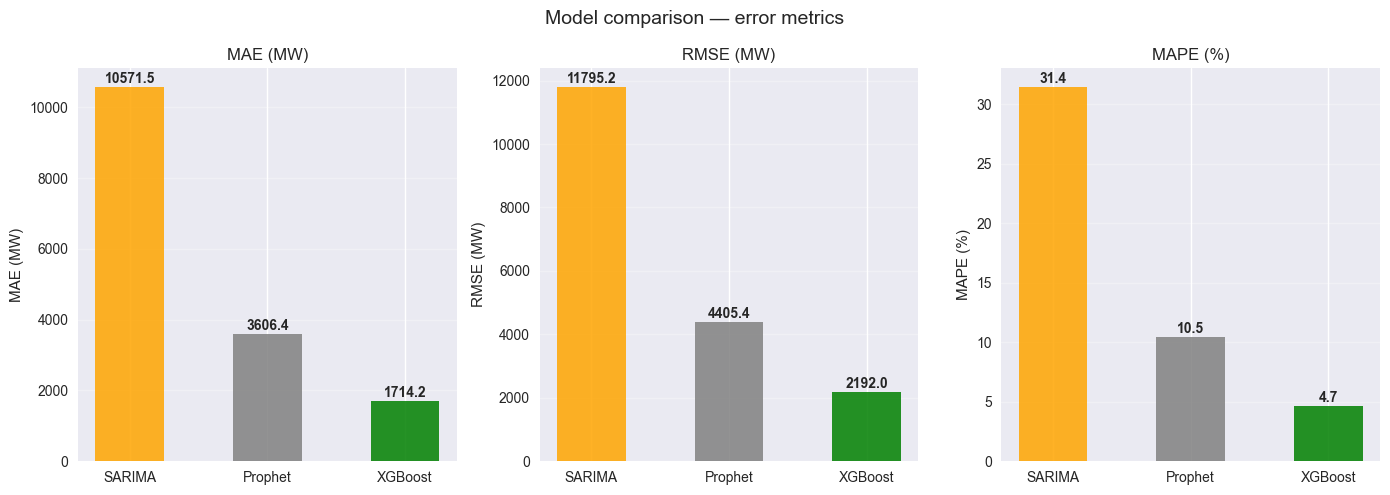

In [18]:
# ── 4.5  MODEL COMPARISON BAR CHART ──────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = {
    'MAE (MW)' : {'SARIMA': mae_sarima,  'Prophet': mae_prophet,  'XGBoost': mae_xgb},
    'RMSE (MW)': {'SARIMA': rmse_sarima, 'Prophet': rmse_prophet, 'XGBoost': rmse_xgb},
    'MAPE (%)'  : {'SARIMA': mape_sarima, 'Prophet': mape_prophet, 'XGBoost': mape_xgb},
}
bar_colors = [colors['sarima'], colors['prophet'], colors['xgb']]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(vals.keys(), vals.values(),
                  color=bar_colors, alpha=0.85, edgecolor='none', width=0.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(vals.values()) * 0.01,
                f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model comparison — error metrics', fontsize=14)
plt.tight_layout()
plt.show()

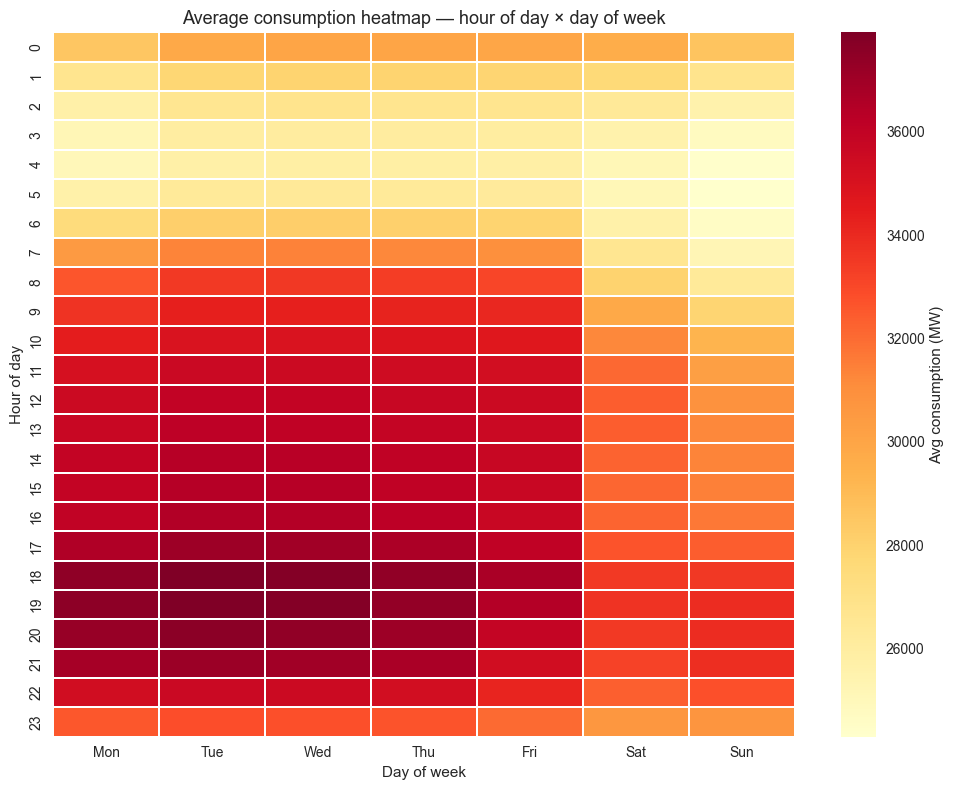

In [19]:
# ── 4.6  CONSUMPTION HEATMAP (HOUR × DAY OF WEEK) ────────────────────────────
pivot = df['consumption'].groupby([df.index.hour, df.index.dayofweek]).mean().unstack()
pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax,
            linewidths=0.3, annot=False,
            cbar_kws={'label': 'Avg consumption (MW)'})
ax.set_title('Average consumption heatmap — hour of day × day of week', fontsize=13)
ax.set_xlabel('Day of week')
ax.set_ylabel('Hour of day')
plt.tight_layout()
plt.show()

In [20]:
# ── 4.7  FINAL SUMMARY ────────────────────────────────────────────────────────
print("=" * 55)
print("  PJME HOURLY — TIME SERIES ANALYSIS SUMMARY")
print("=" * 55)
print(f"  Dataset     : 2002–2018  |  {len(df):,} hourly observations")
print(f"  Mean demand : {df['consumption'].mean():.0f} MW")
print(f"  Range       : {df['consumption'].min():.0f} – {df['consumption'].max():.0f} MW")
print()
print("  Model performance (1-week holdout):")
print(f"  {'Model':<10} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print(f"  {'-'*36}")
print(f"  {'SARIMA':<10} {mae_sarima:>7.0f}  {rmse_sarima:>7.0f}  {mape_sarima:>6.2f}%")
print(f"  {'Prophet':<10} {mae_prophet:>7.0f}  {rmse_prophet:>7.0f}  {mape_prophet:>6.2f}%")
print(f"  {'XGBoost':<10} {mae_xgb:>7.0f}  {rmse_xgb:>7.0f}  {mape_xgb:>6.2f}%")
print()
print(f"  🥇 Best model : XGBoost (MAPE {mape_xgb:.2f}%)")
print(f"  🔑 Top features: lag_168, lag_24, hour, dayofyear")
print("=" * 55)

  PJME HOURLY — TIME SERIES ANALYSIS SUMMARY
  Dataset     : 2002–2018  |  145,392 hourly observations
  Mean demand : 32056 MW
  Range       : 14544 – 51472 MW

  Model performance (1-week holdout):
  Model           MAE     RMSE     MAPE
  ------------------------------------
  SARIMA       10571    11795   31.44%
  Prophet       3606     4405   10.48%
  XGBoost       1714     2192    4.68%

  🥇 Best model : XGBoost (MAPE 4.68%)
  🔑 Top features: lag_168, lag_24, hour, dayofyear
